In [1]:
import pandas as pd 
import numpy as np 
import scipy as sp 
import json 
import matplotlib.pyplot as plt

import os 
from pathlib import Path 

import ast 

In [2]:
wd = os.getcwd()
wd

'c:\\Users\\57305\\Documents\\FTZ_model_2.0\\final_results\\preliminary_analysis_pso_gen_rand'

In [3]:
file_name = "results.csv"
data_path2 = os.path.join(wd, file_name)

data_path2

'c:\\Users\\57305\\Documents\\FTZ_model_2.0\\final_results\\preliminary_analysis_pso_gen_rand\\results.csv'

In [4]:

df = pd.read_csv(data_path2)

In [5]:
df = df.drop_duplicates(['env_name','algorithm','run','seed']).reset_index(drop=True)
len(df) 

3360

In [6]:
df.head

<bound method NDFrame.head of                         env_name  run algorithm     seed  \
0                Linear_standard    6   generic   998841   
1                Linear_standard   17   generic   960720   
2                Linear_standard   12   generic   987631   
3                Linear_standard    4   generic   914042   
4                Linear_standard   13   generic  1160317   
...                          ...  ...       ...      ...   
3355  Mixed Test Graph_perturbed   37    random   886123   
3356  Mixed Test Graph_perturbed   36    random   703664   
3357  Mixed Test Graph_perturbed   38    random   888709   
3358  Mixed Test Graph_perturbed   39    random   984369   
3359  Mixed Test Graph_perturbed   40    random  1167215   

                                             best_curve  best_value  \
0     [38.75, 38.75, 38.75, 38.9, 39.05, 39.2, 39.2,...       39.35   
1     [38.3, 38.45, 38.45, 38.6, 38.9, 38.9, 38.9, 3...       39.35   
2     [38.9, 39.05, 39.05, 39.05, 39

In [7]:
df.columns

Index(['env_name', 'run', 'algorithm', 'seed', 'best_curve', 'best_value',
       'best_genome', 'all_best_genomes', 'elapsed_sec', 'success'],
      dtype='object')

In [8]:
df_curves = df[['env_name','run','seed','algorithm','best_curve']].copy()
df_curves.head(20)

,env_name,run,seed,algorithm,best_curve
0,Linear_standard,6,998841,generic,"[38.75, 38.75, 38.75, 38.9, 39.05, 39.2, 39.2,..."
1,Linear_standard,17,960720,generic,"[38.3, 38.45, 38.45, 38.6, 38.9, 38.9, 38.9, 3..."
2,Linear_standard,12,987631,generic,"[38.9, 39.05, 39.05, 39.05, 39.05, 39.05, 39.0..."
3,Linear_standard,4,914042,generic,"[39.05, 39.05, 39.2, 39.2, 39.2, 39.2, 39.2, 3..."
4,Linear_standard,13,1160317,generic,"[38.75, 38.75, 38.9, 39.05, 39.05, 39.05, 39.2..."
5,Linear_standard,18,1390245,generic,"[38.9, 38.9, 39.05, 39.05, 39.05, 39.05, 39.2,..."
6,Linear_standard,22,788817,generic,"[38.75, 38.9, 39.05, 39.05, 39.2, 39.35, 39.35..."
7,Linear_standard,19,808129,generic,"[38.45, 38.6, 38.75, 38.75, 38.75, 38.9, 39.05..."
8,Linear_standard,5,1415018,generic,"[38.75, 38.9, 38.9, 39.05, 39.2, 39.2, 39.35, ..."
9,Linear_standard,2,855307,generic,"[38.45, 38.6, 38.6, 38.9, 38.9, 38.9, 39.05, 3..."


In [9]:
num_seeds_unicos = df_curves['seed'].nunique()
print(num_seeds_unicos)


3207


In [10]:
num_seeds_unicos = df_curves['run'].nunique()
print(num_seeds_unicos)


40


In [11]:
num_seeds_unicos = df_curves['algorithm'].nunique()
print(num_seeds_unicos)

3


In [12]:
num_seeds_unicos = df_curves['env_name'].nunique()
print(num_seeds_unicos)

28


In [13]:
import ast
import numpy as np
import pandas as pd

# Asegurar copia limpia
df_chk = df[['env_name','algorithm','run','seed','best_curve']].copy()

# 1) Normalizar best_curve para que siempre sea una lista si es posible
def normalize_curve(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, pd.Series):
        return x.tolist()
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                return list(ast.literal_eval(s))
            except:
                return x   # dejar como string "cruda"
    return x  # si no es lista, queda como está

df_chk['best_curve_norm'] = df_chk['best_curve'].apply(normalize_curve)

# 2) Detectar curvas que NO son listas (problema grave)
not_lists = df_chk[df_chk['best_curve_norm'].apply(lambda x: not isinstance(x, list))]
print("❌ Curvas que no son listas (requieren limpieza):", len(not_lists))
display(not_lists.head())

# 3) Para las curvas que sí son listas, revisamos elemento por elemento
def inspect_curve(lst):
    issues = {
        'has_non_numeric': False,
        'has_inf': False,
        'has_nan': False
    }
    for v in lst:
        # Intentar convertir a número
        try:
            val = float(v)
            # revisar infinito / nan
            if np.isinf(val):
                issues['has_inf'] = True
            if np.isnan(val):
                issues['has_nan'] = True
        except Exception:
            issues['has_non_numeric'] = True
    return pd.Series(issues)

df_good = df_chk[df_chk['best_curve_norm'].apply(lambda x: isinstance(x, list))].copy()
df_issues = df_good.join(df_good['best_curve_norm'].apply(inspect_curve))

# 4) Resumen global
print("\n=== RESUMEN GLOBAL ===")
print(df_issues[['has_non_numeric','has_inf','has_nan']].sum())

# 5) Ver ejemplos concretos por tipo de problema
print("\n🔎 Ejemplos: hay valores no numéricos")
display(df_issues[df_issues['has_non_numeric']].head())

print("\n🔎 Ejemplos: hay valores infinitos")
display(df_issues[df_issues['has_inf']].head())

print("\n🔎 Ejemplos: hay valores NaN")
display(df_issues[df_issues['has_nan']].head())


❌ Curvas que no son listas (requieren limpieza): 1


,env_name,algorithm,run,seed,best_curve,best_curve_norm
1120,Sequential Mergers with External Inputs_perturbed,pso,1,912874,"[226.65, -inf, 228.9, 231.75, 231.75, 238.95, ...","[226.65, -inf, 228.9, 231.75, 231.75, 238.95, ..."



=== RESUMEN GLOBAL ===
has_non_numeric    0
has_inf            0
has_nan            0
dtype: int64

🔎 Ejemplos: hay valores no numéricos


,env_name,algorithm,run,seed,best_curve,best_curve_norm,has_non_numeric,has_inf,has_nan



🔎 Ejemplos: hay valores infinitos


,env_name,algorithm,run,seed,best_curve,best_curve_norm,has_non_numeric,has_inf,has_nan



🔎 Ejemplos: hay valores NaN


,env_name,algorithm,run,seed,best_curve,best_curve_norm,has_non_numeric,has_inf,has_nan


In [14]:
import ast
import numpy as np
import pandas as pd

# --- 1) Normalizar las curvas a listas reales ---
def normalize_curve(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, pd.Series):
        return x.tolist()
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                return list(ast.literal_eval(s))
            except:
                return x
    return x

df['best_curve'] = df['best_curve'].apply(normalize_curve)

# Nos quedamos solo con filas donde la curva es lista
df = df[df['best_curve'].apply(lambda x: isinstance(x, list))].reset_index(drop=True)


# --- 2) Función para corregir -inf y +inf en una curva ---
def fix_infs(curve):
    arr = []
    for v in curve:
        try:
            val = float(v)
        except:
            arr.append(np.nan)
            continue
        
        if np.isinf(val):  # incluye +inf y -inf
            if len(arr) > 0 and np.isfinite(arr[-1]):
                arr.append(arr[-1])         # usar valor previo válido
            else:
                arr.append(np.nan)          # temporal NaN si es el primer elemento
        else:
            arr.append(val)

    arr = np.array(arr, dtype=float)

    # Forward fill
    for i in range(1, len(arr)):
        if np.isnan(arr[i]) and np.isfinite(arr[i-1]):
            arr[i] = arr[i-1]

    # Si el primer valor quedó NaN → usar primer valor válido hacia adelante
    if np.isnan(arr[0]):
        finite = arr[np.isfinite(arr)]
        if len(finite) > 0:
            arr[0] = finite[0]

    return arr.tolist()


# --- 3) Aplicar corrección a TODAS las curvas ---
df['best_curve'] = df['best_curve'].apply(fix_infs)

print("✅ Listo. Todos los -inf y +inf fueron reemplazados correctamente.")


✅ Listo. Todos los -inf y +inf fueron reemplazados correctamente.


In [15]:
len(df)    # ← debería dar 3360


3359

In [16]:
import re
import ast
import numpy as np
import pandas as pd

# --- 0) Subset base limpio ---
df_chk = df[['env_name', 'algorithm', 'run', 'seed', 'best_curve']].copy()

# --- 1) Normalización MUY robusta ---
SAFE_NAMES = {
    'inf': float('inf'),
    'Infinity': float('inf'),
    'nan': float('nan'),
    'NaN': float('nan'),
    'None': None,
    # negativos se manejan por el signo en el string
}

def strip_ellipses(s: str) -> str:
    # elimina '...' y '…' que suelen ser truncados de impresión
    s = s.replace('…', '')
    s = s.replace('...', '')
    return s

def extract_inside_array(s: str) -> str:
    # maneja strings tipo 'array([1, 2, -inf])' → '[1, 2, -inf]'
    m = re.search(r'array\s*\(\s*(\[.*\])\s*\)', s, flags=re.DOTALL | re.IGNORECASE)
    return m.group(1) if m else s

def normalize_curve(x):
    # casos ya estructurados
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return list(x)

    # si es string, intentamos varios parseos
    if isinstance(x, str):
        s = x.strip()
        s = strip_ellipses(s)
        s = extract_inside_array(s)

        # caso típico de lista
        if s.startswith('[') and s.endswith(']'):
            # 1) literal_eval
            try:
                obj = ast.literal_eval(s)
                if isinstance(obj, (list, tuple, np.ndarray, pd.Series)):
                    return list(obj)
            except Exception:
                pass
            # 2) eval seguro con nombres permitidos (inf, nan, Infinity)
            try:
                obj = eval(s, {"__builtins__": None}, SAFE_NAMES)
                if isinstance(obj, (list, tuple, np.ndarray, pd.Series)):
                    return list(obj)
            except Exception:
                pass

        # último intento: parsear números entre corchetes por split (muy laxo)
        # Solo si parece lista: contiene '[' y ']'
        if '[' in s and ']' in s:
            body = s[s.find('[')+1 : s.rfind(']')]
            # separa por coma
            parts = [p.strip() for p in body.split(',')]
            out = []
            ok = True
            for p in parts:
                if p == '':
                    continue
                # mapea tokens inf/nan
                low = p.lower()
                if low in ('inf', '+inf', 'infinity', '+infinity'):
                    out.append(float('inf'))
                elif low in ('-inf', '-infinity'):
                    out.append(float('-inf'))
                elif low in ('nan', 'none'):
                    out.append(float('nan'))
                else:
                    try:
                        out.append(float(p))
                    except Exception:
                        ok = False
                        break
            if ok:
                return out

        # si nada funcionó, retorna string crudo
        return x

    # cualquier otro tipo, lo devolvemos tal cual
    return x

df_chk['best_curve_norm'] = df_chk['best_curve'].apply(normalize_curve)

# --- 2) Detectores de ±inf ---
def contains_inf_list(lst):
    try:
        arr = np.array(lst, dtype=float)
        return np.isinf(arr).any()
    except Exception:
        return False

INF_TOKEN_RE = re.compile(r'(?<!\w)-?inf(?!\w)', flags=re.IGNORECASE)

def contains_inf_text(s):
    try:
        return bool(INF_TOKEN_RE.search(s))
    except Exception:
        return False

# --- 3) Separar casos parseados (listas) vs no parseados (strings) ---
is_list = df_chk['best_curve_norm'].apply(lambda x: isinstance(x, list))
is_str  = df_chk['best_curve_norm'].apply(lambda x: isinstance(x, str))

df_lists = df_chk[is_list].copy()
df_texts = df_chk[is_str].copy()

# --- 4) Filtrar las que tienen ±inf ---
df_inf_lists = df_lists[df_lists['best_curve_norm'].apply(contains_inf_list)].copy()

# en textos no parseados, buscar token 'inf' textual
df_inf_texts = df_texts[df_texts['best_curve_norm'].apply(contains_inf_text)].copy()

# Posiciones exactas dentro de listas
def extract_inf_positions(lst):
    pos = []
    for i, v in enumerate(lst):
        try:
            val = float(v)
            if np.isinf(val):
                pos.append((i, val))
        except Exception:
            pass
    return pos

if not df_inf_lists.empty:
    df_inf_lists['inf_positions'] = df_inf_lists['best_curve_norm'].apply(extract_inf_positions)

# --- 5) Reporte ---
print("=== RESUMEN DETECCIÓN ±inf ===")
print(f"Curvas parseadas (listas) con ±inf: {len(df_inf_lists)}")
print(f"Curvas NO parseadas (strings) que contienen el token 'inf': {len(df_inf_texts)}")

# Muestras/inspección
if not df_inf_lists.empty:
    print("\n--- Curvas LISTA con ±inf (posiciones incluidas) ---")
    display(df_inf_lists[['env_name','algorithm','run','seed','inf_positions','best_curve_norm']])

if not df_inf_texts.empty:
    print("\n--- Curvas STRING con 'inf' textual (no parseadas) ---")
    # ojo: aquí best_curve_norm es string, mostramos ambas columnas para comparar
    display(df_inf_texts[['env_name','algorithm','run','seed','best_curve','best_curve_norm']])


=== RESUMEN DETECCIÓN ±inf ===
Curvas parseadas (listas) con ±inf: 0
Curvas NO parseadas (strings) que contienen el token 'inf': 0


Resumen por (env_name, algorithm):


C:\Users\57305\AppData\Local\Temp\ipykernel_9516\3152383958.py:132: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_group)


,env_name,algorithm,n_runs,length,mean_std_curve
0,All Inputs_perturbed,generic,40,101,"[(353.74125, 1.233188877541597), (354.59625, 1..."
1,All Inputs_perturbed,pso,40,100,"[(353.145, 1.5787775212291508), (353.24625, 1...."
2,All Inputs_perturbed,random,40,101,"[(353.74125, 1.233188877541597), (354.66375, 1..."
3,All Inputs_standard,generic,40,101,"[(362.25, 0.0), (362.25, 0.0), (362.25, 0.0), ..."
4,All Inputs_standard,pso,40,100,"[(362.25, 0.0), (361.725, 3.3203915431767985),..."
5,All Inputs_standard,random,40,101,"[(362.25, 0.0), (362.25, 0.0), (362.25, 0.0), ..."
6,Assembly Tree_perturbed,generic,40,101,"[(729.2375, 5.662401298171875), (734.3975, 5.2..."
7,Assembly Tree_perturbed,pso,40,100,"[(722.49875, 9.141981827304686), (724.32125, 8..."
8,Assembly Tree_perturbed,random,40,101,"[(729.2375, 5.662401298171875), (732.6875, 6.1..."
9,Assembly Tree_standard,generic,40,101,"[(729.47, 0.6144415851311349), (729.6949999999..."


Distribución de largos por grupo:


,env_name,algorithm,count,mean,std,min,25%,50%,75%,max
0,All Inputs_perturbed,generic,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0
1,All Inputs_perturbed,pso,40.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0
2,All Inputs_perturbed,random,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0
3,All Inputs_standard,generic,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0
4,All Inputs_standard,pso,40.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0
5,All Inputs_standard,random,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0
6,Assembly Tree_perturbed,generic,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0
7,Assembly Tree_perturbed,pso,40.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0
8,Assembly Tree_perturbed,random,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0
9,Assembly Tree_standard,generic,40.0,101.0,0.0,101.0,101.0,101.0,101.0,101.0


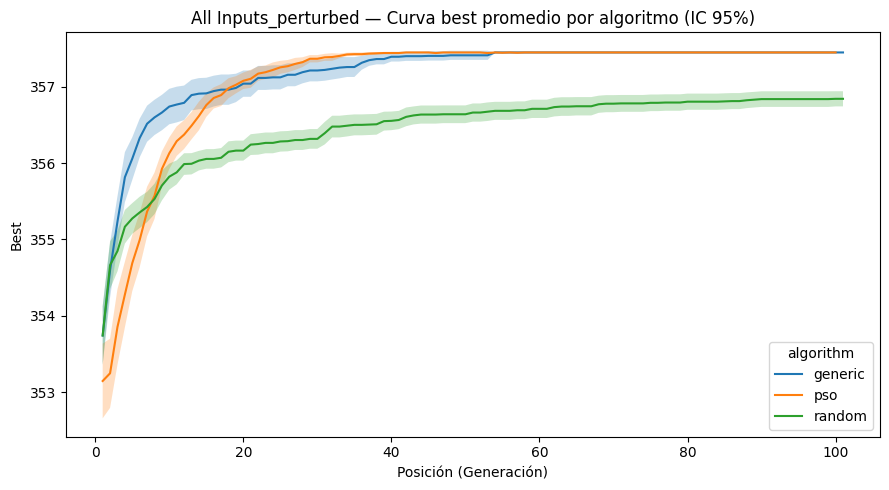

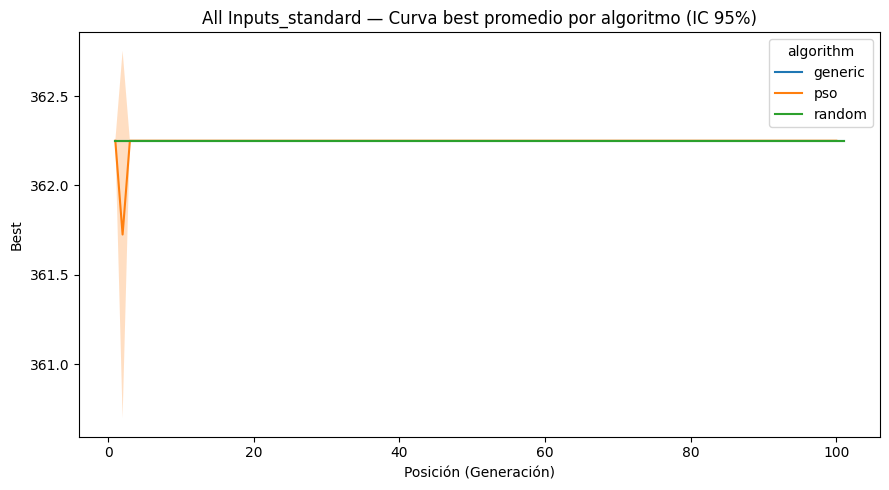

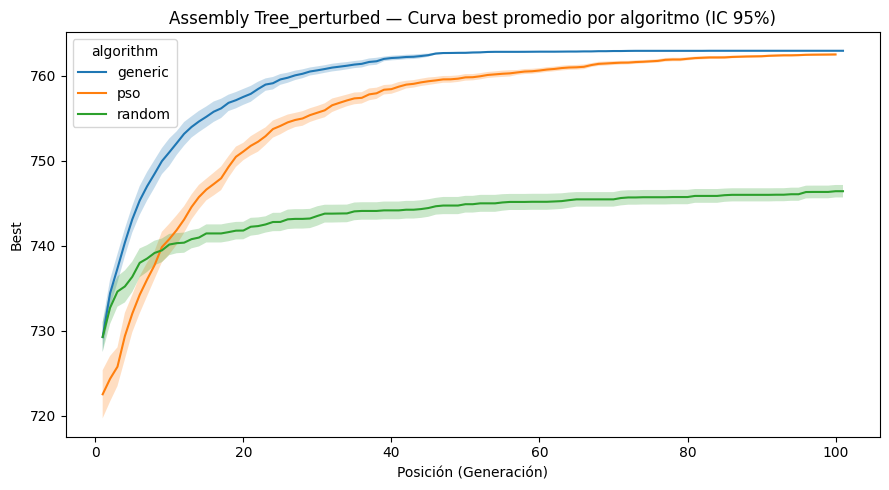

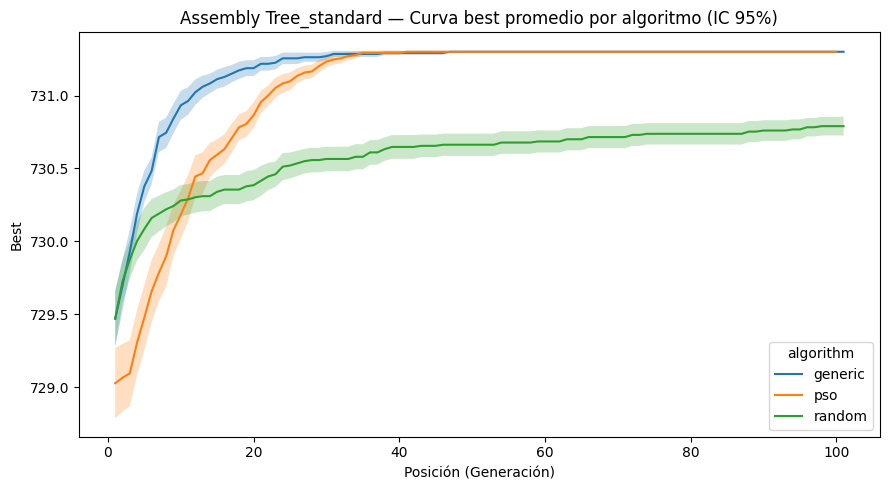

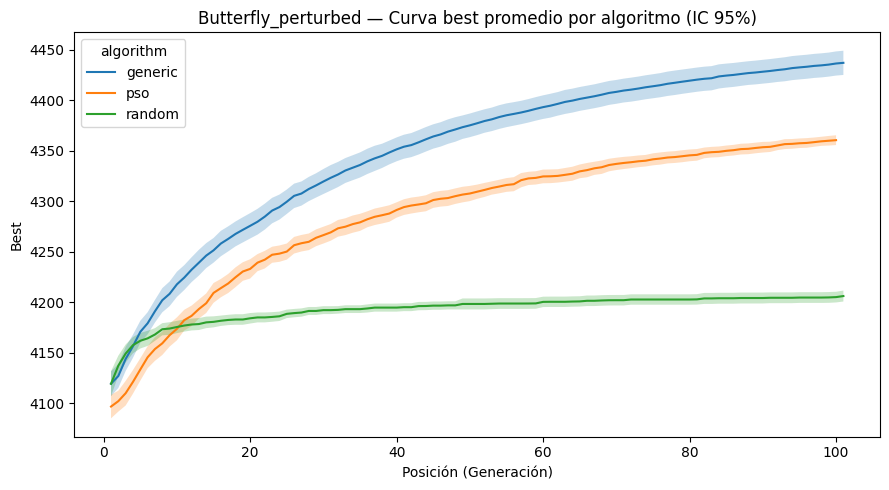

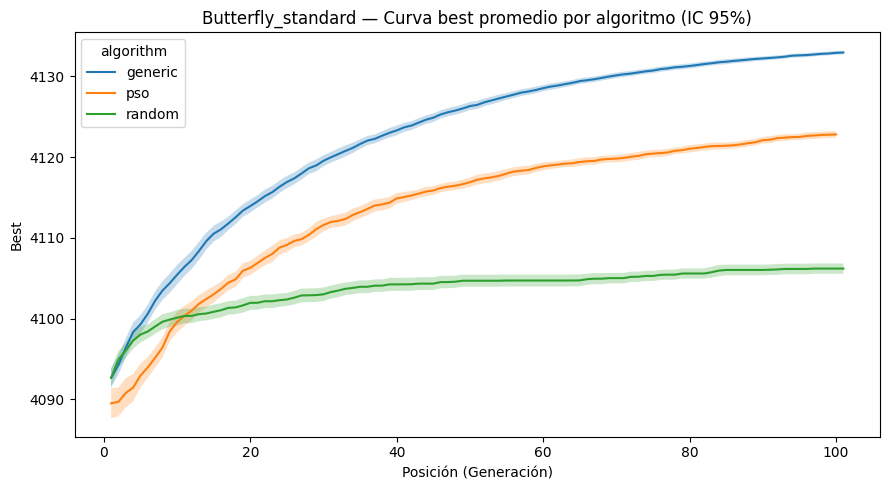

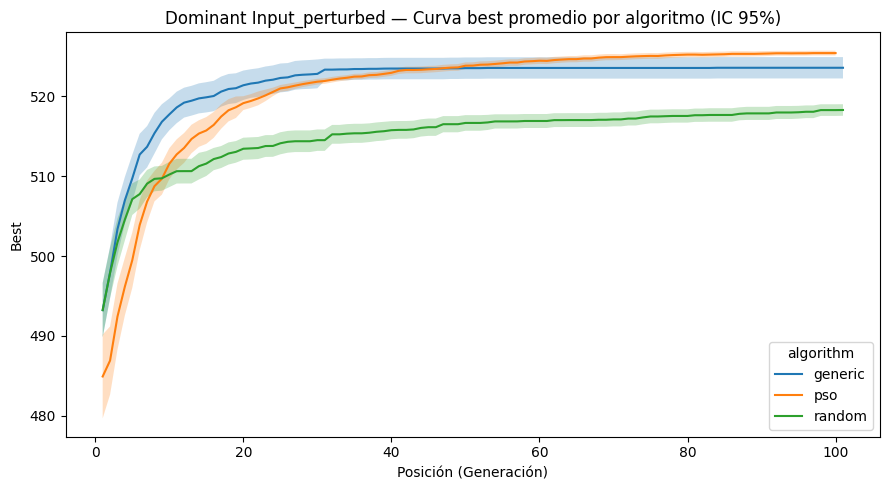

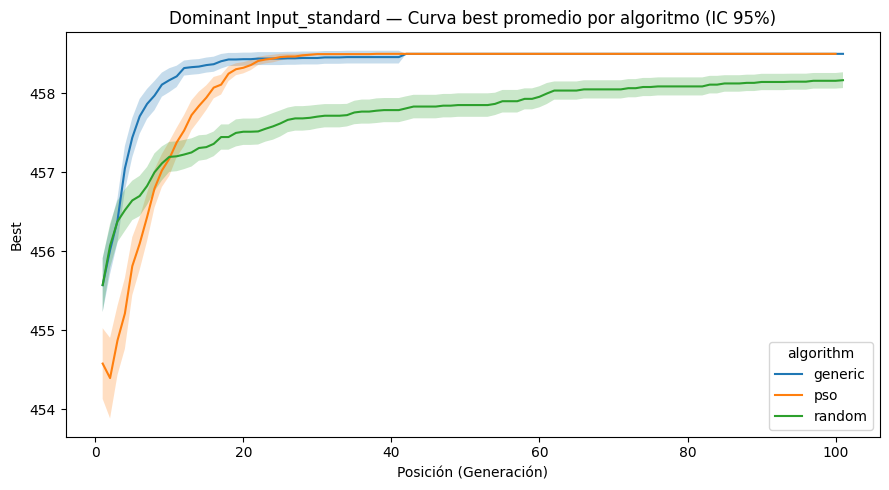

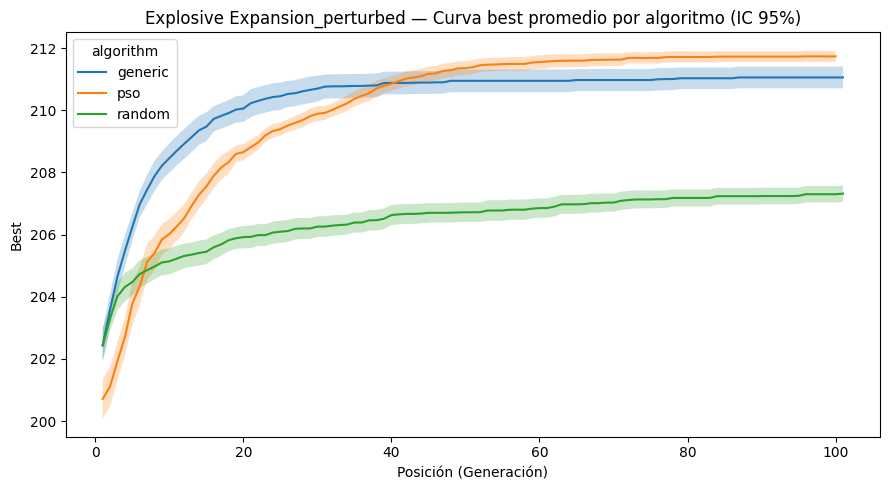

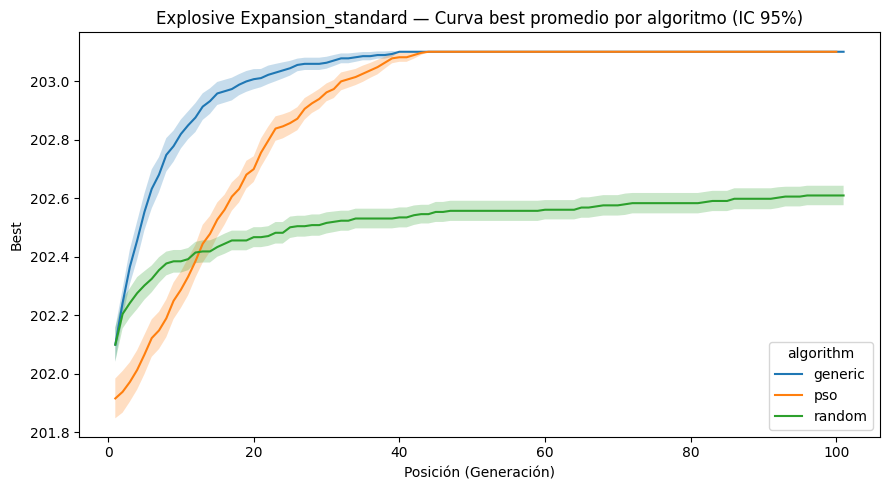

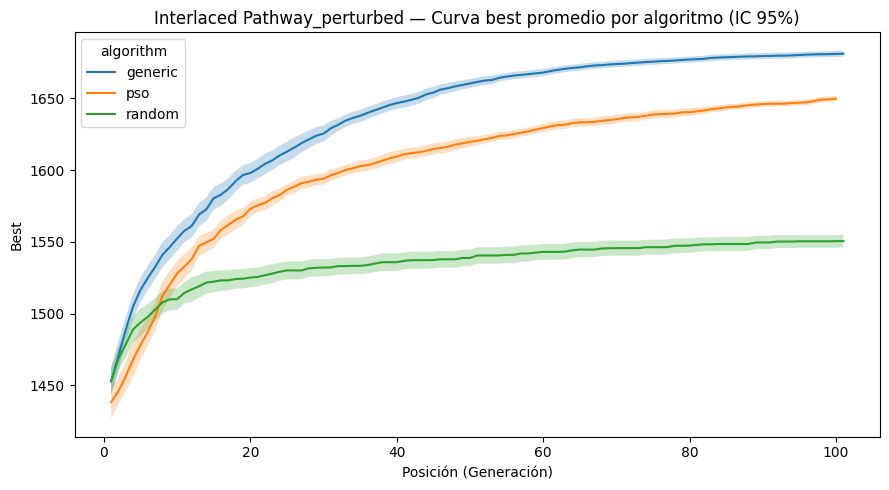

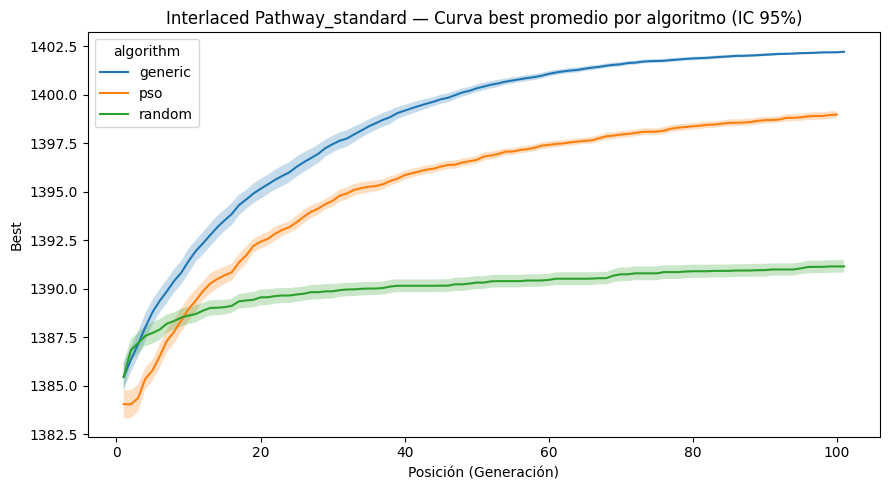

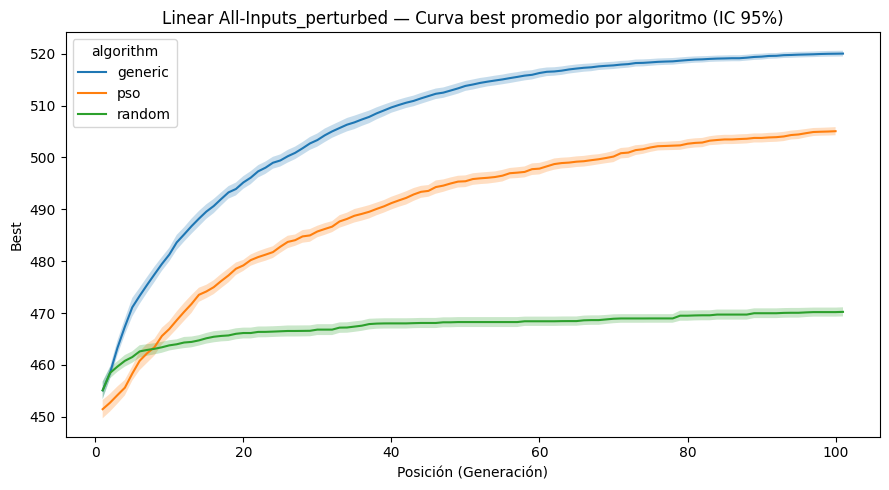

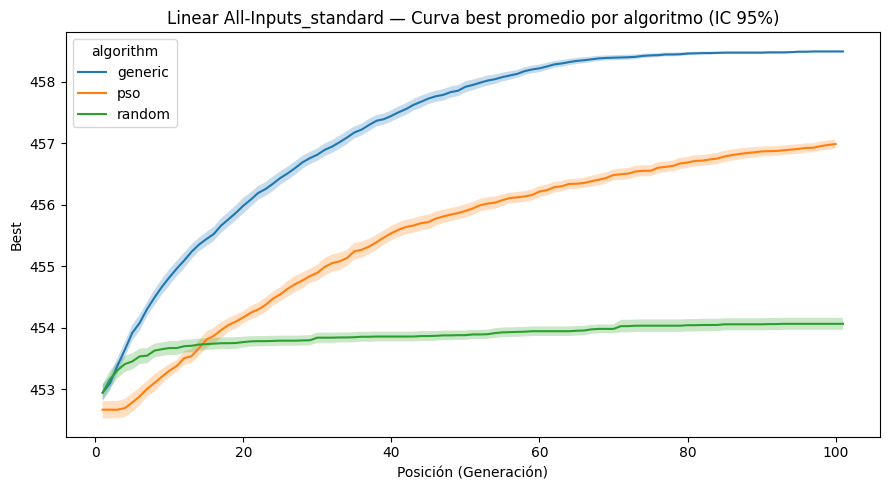

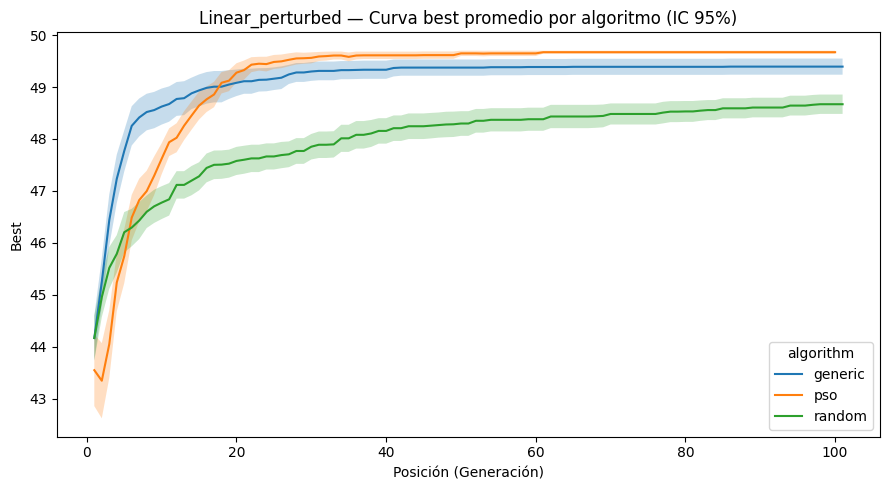

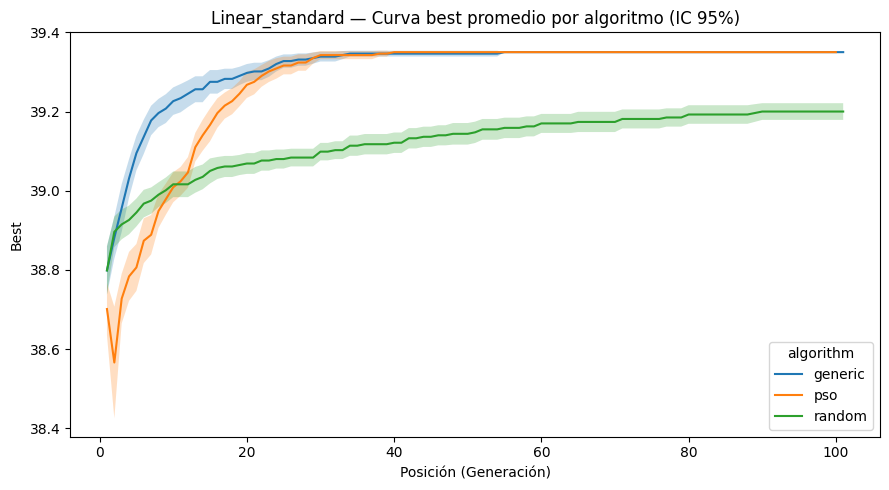

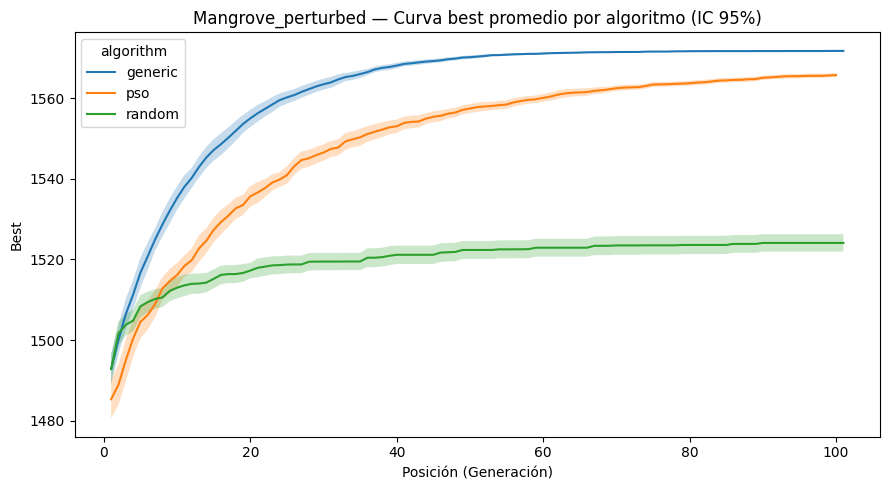

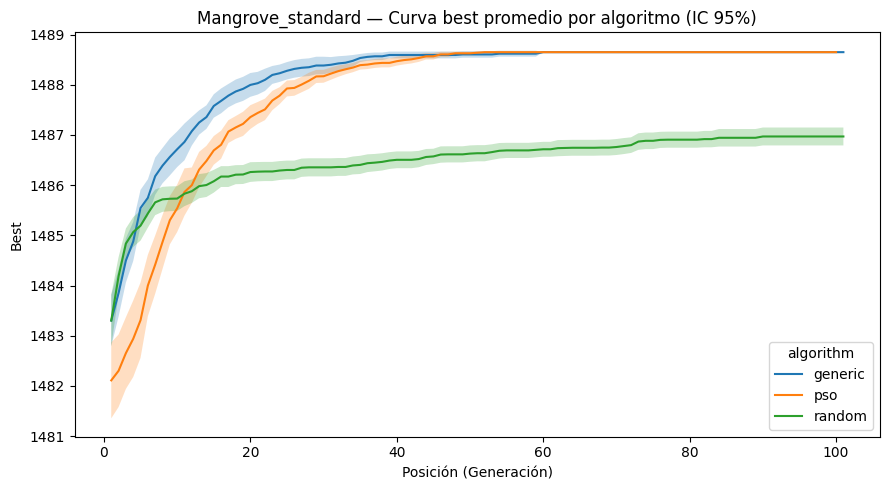

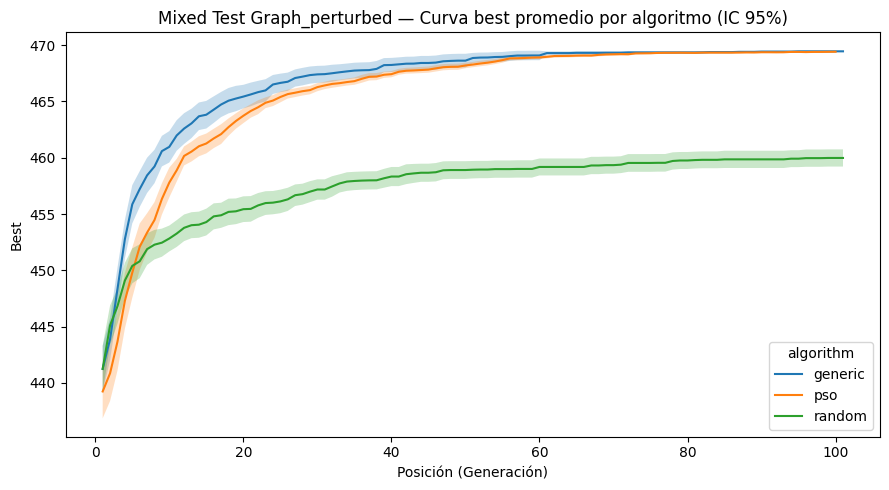

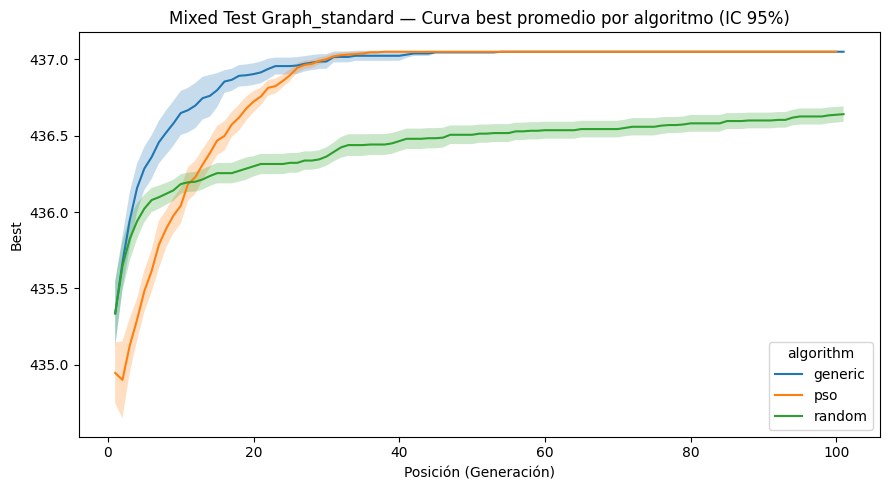

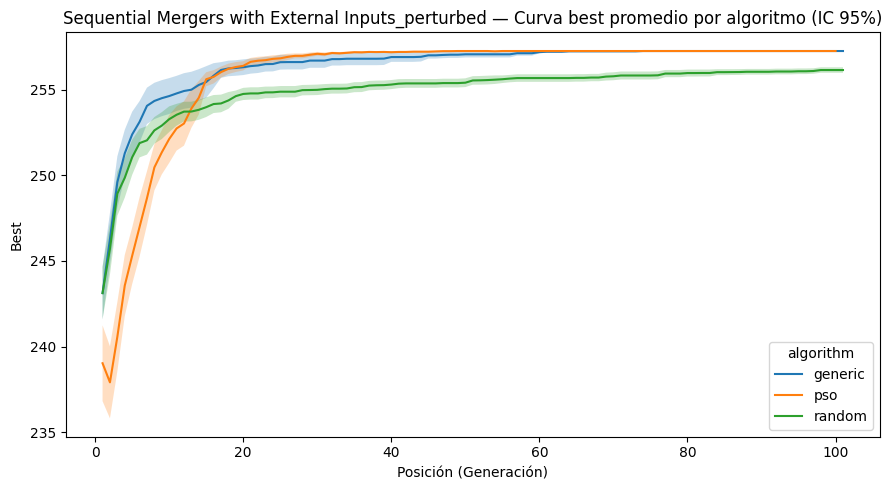

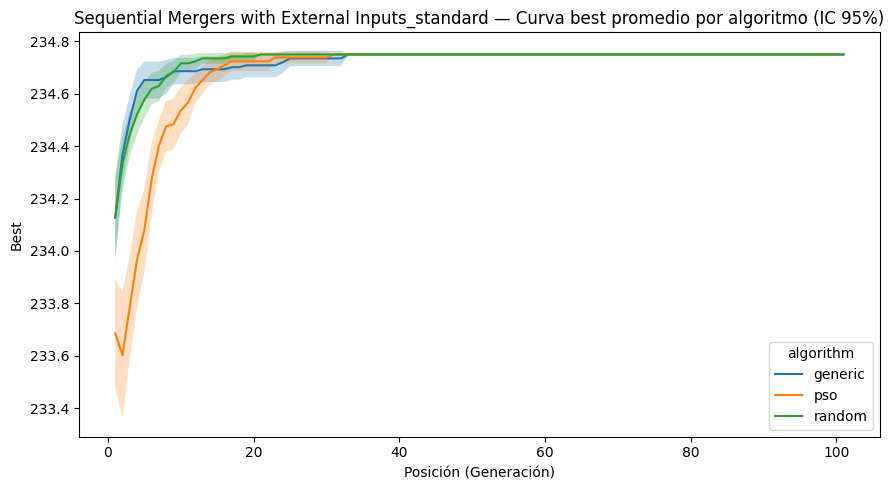

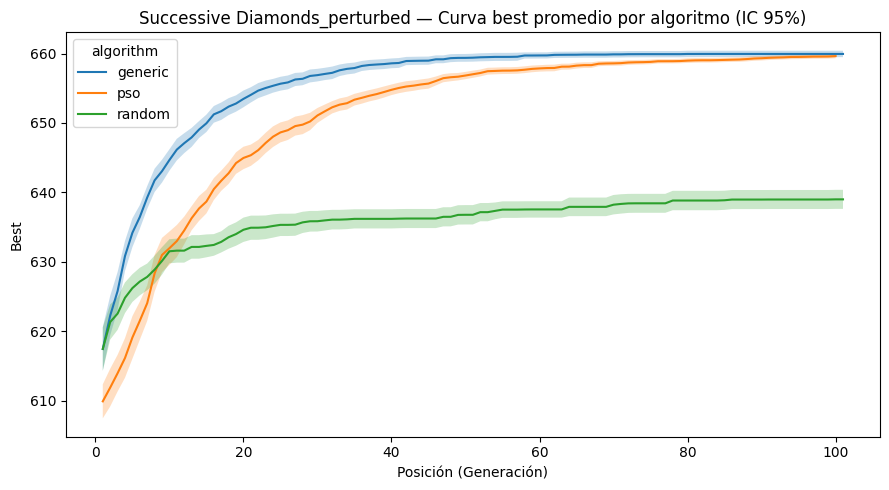

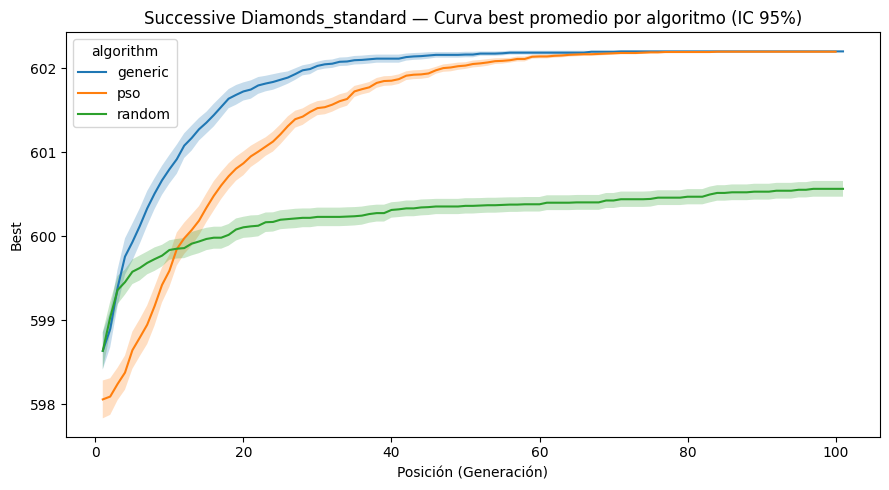

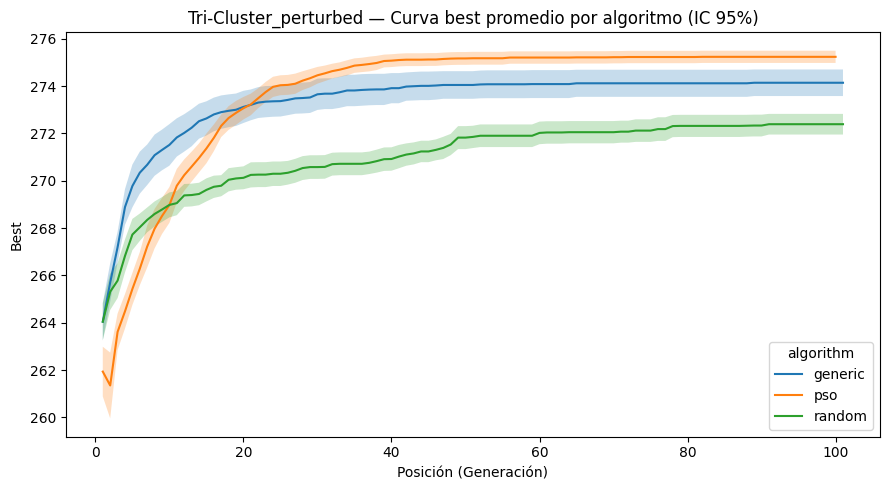

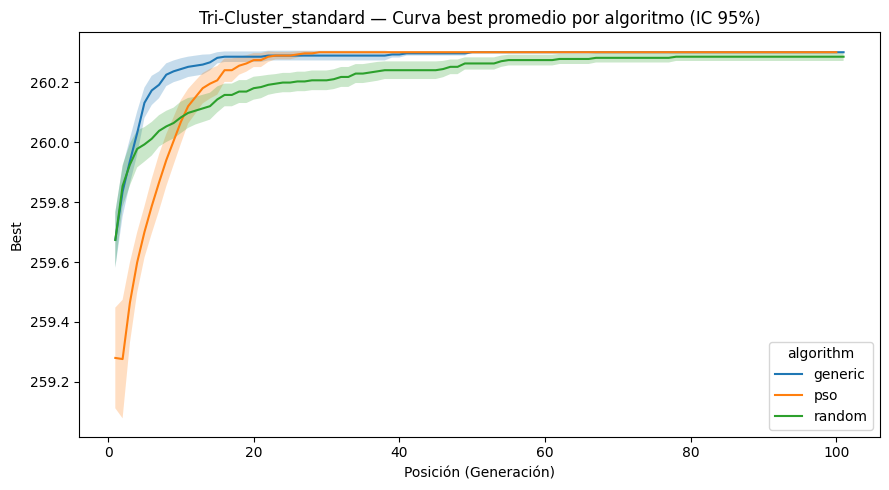

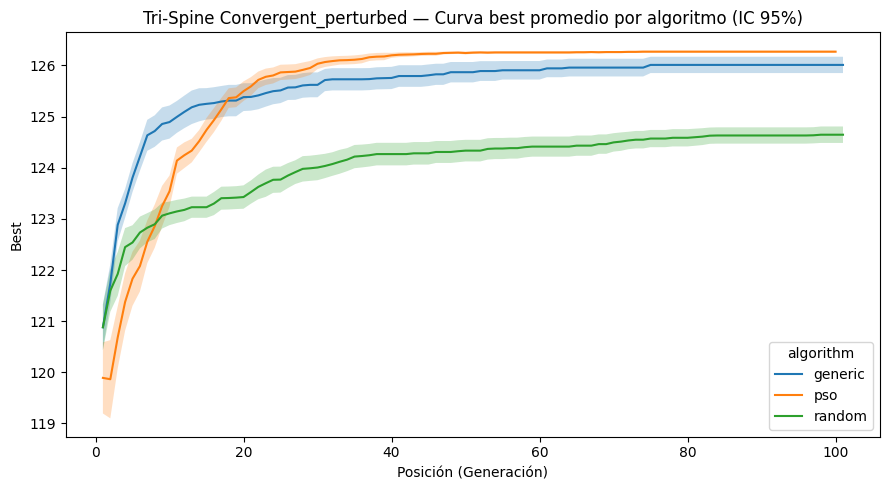

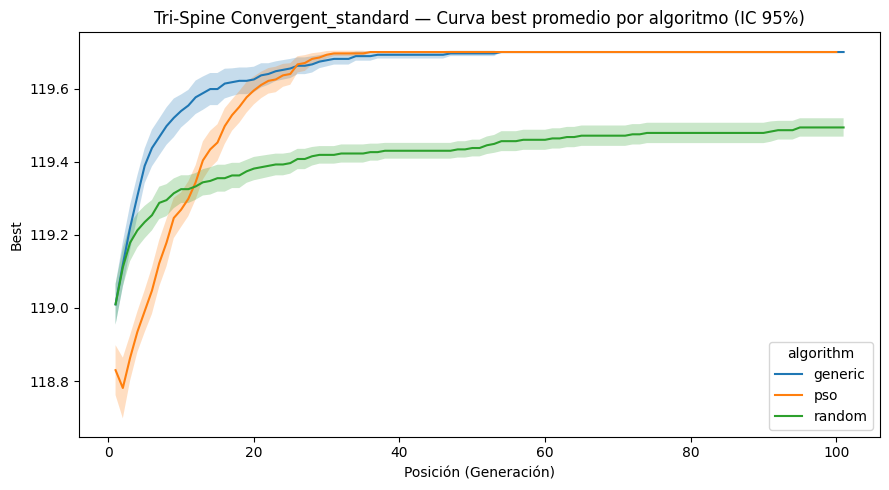

In [17]:
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1) Selección y chequeo de columnas
# ======================
required = {'env_name', 'run', 'algorithm', 'seed', 'best_curve'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas en df: {missing}")

df_curves = df[['env_name','run','seed','algorithm','best_curve']].copy()

# ======================
# 2) Normalización de best_curve a listas reales
# ======================
def parse_list_string(s: str):
    s = s.strip()
    if s.startswith('[') and s.endswith(']'):
        try:
            return list(ast.literal_eval(s))
        except Exception:
            pass
    return None

def normalize_curve(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, pd.Series):
        return x.tolist()
    if isinstance(x, str):
        parsed = parse_list_string(x)
        if parsed is not None:
            return parsed
    if np.isscalar(x):
        return [x]
    return None

df_curves['best_curve'] = df_curves['best_curve'].apply(normalize_curve)

bad = df_curves[df_curves['best_curve'].apply(lambda v: not isinstance(v, list))]
if not bad.empty:
    print("Advertencia: hay filas con 'best_curve' inválido. Ejemplos:")
    display(bad.head())
    raise TypeError("Corrige/normaliza esas filas antes de continuar.")

# ======================
# 3) Limpieza de elementos
# ======================
INF_TOKENS = {'inf', '+inf', '-inf', 'infinity', '+infinity', '-infinity'}

def to_float_or_nan(x):
    if isinstance(x, (int, float, np.floating)):
        return float(x) if np.isfinite(x) else np.nan
    if isinstance(x, str):
        xs = x.strip().lower().replace(',', '')
        if xs in INF_TOKENS:
            return np.nan
        try:
            return float(xs)
        except Exception:
            maybe_list = parse_list_string(x)
            if isinstance(maybe_list, list) and len(maybe_list) == 1:
                return to_float_or_nan(maybe_list[0])
            return np.nan
    return np.nan

df_curves['best_curve'] = df_curves['best_curve'].apply(
    lambda lst: [to_float_or_nan(v) for v in lst]
)

# ======================
# 4) Agregación
# ======================
def summarize_group(gr):
    curves = gr['best_curve'].tolist()
    lengths = [len(c) for c in curves]

    if len(lengths) == 0:
        return pd.Series({'n_runs': 0, 'length': 0,
                          'mean_curve': [], 'std_curve': [], 'mean_std_curve': []})

    L_common = min(lengths)
    arr = np.array([c[:L_common] for c in curves], dtype=float)

    mask_all_valid = np.all(np.isfinite(arr), axis=0)

    if not mask_all_valid.any():
        mean = np.nanmean(arr, axis=0)

        def nanstd_m1(col):
            vals = col[np.isfinite(col)]
            if vals.size >= 2:
                return np.std(vals, ddof=1)
            elif vals.size == 1:
                return 0.0
            else:
                return np.nan

        std = np.array([nanstd_m1(arr[:, j]) for j in range(arr.shape[1])], dtype=float)

        keep = np.isfinite(mean)
        mean = mean[keep]
        std  = std[keep]
        xlen = mean.shape[0]
    else:
        arr_valid = arr[:, mask_all_valid]
        mean = arr_valid.mean(axis=0)
        std  = arr_valid.std(axis=0, ddof=1) if arr_valid.shape[0] >= 2 else np.zeros(arr_valid.shape[1])
        xlen = arr_valid.shape[1]

    mean = mean.tolist()
    std  = std.tolist()
    mean_std = list(zip(mean, std))

    return pd.Series({
        'n_runs': len(curves),
        'length': xlen,
        'mean_curve': mean,
        'std_curve': std,
        'mean_std_curve': mean_std
    })

df_summary = (
    df_curves
    .groupby(['env_name', 'algorithm'], as_index=False)
    .apply(summarize_group)
    .reset_index(drop=True)
)

# ======================
# 5) Sanity checks
# ======================
print("Resumen por (env_name, algorithm):")
display(df_summary[['env_name','algorithm','n_runs','length','mean_std_curve']].head(10))

lens = (
    df_curves
    .assign(len_curve=df_curves['best_curve'].apply(len))
    .groupby(['env_name','algorithm'])['len_curve']
    .describe()
    .reset_index()
)
print("Distribución de largos por grupo:")
display(lens.head(10))

# ======================
# 6) Graficar — AHORA: media ± CI95
# ======================
for env, sub_env in df_summary.groupby('env_name'):
    plt.figure(figsize=(9, 5))
    plt.title(f"{env} — Curva best promedio por algoritmo (IC 95%)")
    plt.xlabel("Posición (Generación)")
    plt.ylabel("Best")

    for _, row in sub_env.iterrows():
        algo   = row['algorithm']
        mean_c = np.asarray(row['mean_curve'], dtype=float)
        std_c  = np.asarray(row['std_curve'], dtype=float)
        n      = row['n_runs']
        L      = row['length']
        if L == 0:
            continue

        x = np.arange(1, L+1, dtype=int)

        # Error estándar e intervalo de confianza (aprox normal)
        stderr = std_c / np.sqrt(n)
        ci95 = 1.96 * stderr

        plt.plot(x, mean_c, label=f"{algo}")
        plt.fill_between(x, mean_c - ci95, mean_c + ci95, alpha=0.25)

    plt.legend(title="algorithm")
    plt.tight_layout()
    plt.show()



In [18]:
df_summary[['env_name','algorithm','n_runs']]


,env_name,algorithm,n_runs
0,All Inputs_perturbed,generic,40
1,All Inputs_perturbed,pso,40
2,All Inputs_perturbed,random,40
3,All Inputs_standard,generic,40
4,All Inputs_standard,pso,40
...,...,...,...
79,Tri-Spine Convergent_perturbed,pso,40
80,Tri-Spine Convergent_perturbed,random,40
81,Tri-Spine Convergent_standard,generic,40
82,Tri-Spine Convergent_standard,pso,40


In [19]:
# Nos quedamos solo con las columnas relevantes
df_basic = df[['env_name','algorithm','run','seed','best_curve']].copy()

# Contamos cuántas filas hay por corrida (env, algo, run, seed)
dupe_counts = (
    df_basic
    .groupby(['env_name','algorithm','run','seed'])
    .size()
    .reset_index(name='count_rows')
    .sort_values('count_rows', ascending=False)
)

print("=== Número de filas por corrida ===")
display(dupe_counts.head(20))


=== Número de filas por corrida ===


,env_name,algorithm,run,seed,count_rows
0,All Inputs_perturbed,generic,1,488498,1
1,All Inputs_perturbed,generic,2,639652,1
2,All Inputs_perturbed,generic,3,862326,1
3,All Inputs_perturbed,generic,4,678346,1
4,All Inputs_perturbed,generic,5,1328632,1
5,All Inputs_perturbed,generic,6,1157378,1
6,All Inputs_perturbed,generic,7,765525,1
7,All Inputs_perturbed,generic,8,847194,1
8,All Inputs_perturbed,generic,9,646853,1
9,All Inputs_perturbed,generic,10,1269172,1


In [20]:
dupes_only = dupe_counts[dupe_counts['count_rows'] > 1]

print("=== Corridas guardadas múltiples veces ===")
display(dupes_only)


=== Corridas guardadas múltiples veces ===


,env_name,algorithm,run,seed,count_rows


In [21]:
import ast
import numpy as np
import pandas as pd

# Partimos de df y del conteo que ya hiciste:
df_basic = df[['env_name','algorithm','run','seed','best_curve']].copy()

dupe_counts = (
    df_basic
    .groupby(['env_name','algorithm','run','seed'])
    .size()
    .reset_index(name='count_rows')
    .sort_values('count_rows', ascending=False)
)
dupes_only = dupe_counts[dupe_counts['count_rows'] > 1].copy()

def curve_len(x):
    # lista/tupla/array/serie
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return len(x)
    # string que parece lista
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                obj = ast.literal_eval(s)
                if isinstance(obj, (list, tuple, np.ndarray, pd.Series)):
                    return len(obj)
            except Exception:
                pass
    return np.nan

# Tomar una fila representativa por corrida duplicada y medir largo
sample_rows = []
for idx, row in dupes_only.iterrows():
    sub = df_basic[
        (df_basic['env_name']==row['env_name']) &
        (df_basic['algorithm']==row['algorithm']) &
        (df_basic['run']==row['run']) &
        (df_basic['seed']==row['seed'])
    ]
    # largo de la curva de la PRIMERA fila del grupo
    L = curve_len(sub.iloc[0]['best_curve'])
    # ¿cuántas curvas distintas hay en el grupo (como string)?
    nunique_curves = sub['best_curve'].astype(str).nunique()
    sample_rows.append({
        'env_name': row['env_name'],
        'algorithm': row['algorithm'],
        'run': row['run'],
        'seed': row['seed'],
        'count_rows': int(row['count_rows']),
        'curve_len_first': int(L) if pd.notna(L) else np.nan,
        'same_curve_all_rows': (nunique_curves == 1)
    })

check_df = pd.DataFrame(sample_rows).sort_values('count_rows', ascending=False)
print("=== Verificación duplicados vs largo de la curva ===")
display(check_df.head(20))


KeyError: 'count_rows'

In [ ]:
one = dupes_only.iloc[0]
env, algo, run, seed = one[['env_name','algorithm','run','seed']]

subset = df_basic[
    (df_basic['env_name']==env) &
    (df_basic['algorithm']==algo) &
    (df_basic['run']==run) &
    (df_basic['seed']==seed)
]

print("=== Filas duplicadas — necesitamos ver TODAS sus columnas ===")
display(subset.head(28))   # no solo best_curve, TODAS
display(subset.tail(28))


=== Filas duplicadas — necesitamos ver TODAS sus columnas ===


,env_name,algorithm,run,seed,best_curve
22,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
142,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
382,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
742,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
1222,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
1822,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
2542,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
3382,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
4342,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
5422,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."


,env_name,algorithm,run,seed,best_curve
22,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
142,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
382,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
742,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
1222,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
1822,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
2542,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
3382,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
4342,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."
5422,Linear_standard,generic,25,1166003,"[38.75, 38.9, 39.05, 39.2, 39.35, 39.35, 39.35..."


In [ ]:
df_basic = df[['env_name','algorithm','run','seed','best_curve']].copy()

# Contar cuántas filas existen por corrida
dupe_counts = (
    df_basic
    .groupby(['env_name','algorithm','run','seed'])
    .size()
    .reset_index(name='count_rows')
)

# Filtrar SOLO corridas duplicadas (count_rows > 1)
duplicated_runs = dupe_counts[dupe_counts['count_rows'] > 1].copy()

print("=== Total corridas duplicadas ===")
print(len(duplicated_runs))

print("\n=== Ejemplo de corridas duplicadas ===")
display(duplicated_runs.head(20))


=== Total corridas duplicadas ===
3240

=== Ejemplo de corridas duplicadas ===


,env_name,algorithm,run,seed,count_rows
0,All Inputs_perturbed,generic,1,488498,13
1,All Inputs_perturbed,generic,2,639652,13
2,All Inputs_perturbed,generic,3,862326,13
3,All Inputs_perturbed,generic,4,678346,13
4,All Inputs_perturbed,generic,5,1328632,13
5,All Inputs_perturbed,generic,6,1157378,13
6,All Inputs_perturbed,generic,7,765525,13
7,All Inputs_perturbed,generic,8,847194,13
8,All Inputs_perturbed,generic,9,646853,13
9,All Inputs_perturbed,generic,10,1269172,13


In [ ]:
print("=== TODAS las corridas duplicadas ===")
display(duplicated_runs.sort_values(['env_name','algorithm','run','seed']))


=== TODAS las corridas duplicadas ===


,env_name,algorithm,run,seed,count_rows
0,All Inputs_perturbed,generic,1,488498,13
1,All Inputs_perturbed,generic,2,639652,13
2,All Inputs_perturbed,generic,3,862326,13
3,All Inputs_perturbed,generic,4,678346,13
4,All Inputs_perturbed,generic,5,1328632,13
...,...,...,...,...,...
3355,Tri-Spine Convergent_standard,random,36,1657642,22
3356,Tri-Spine Convergent_standard,random,37,1000623,22
3357,Tri-Spine Convergent_standard,random,38,1186874,22
3358,Tri-Spine Convergent_standard,random,39,1039888,22


In [ ]:
print("=== Distribución del número de duplicados ===")
display(
    duplicated_runs['count_rows']
    .value_counts()
    .rename_axis('count_rows')
    .reset_index(name='num_corridas')
)


=== Distribución del número de duplicados ===


,count_rows,num_corridas
0,13,120
1,14,120
2,23,120
3,24,120
4,17,120
5,18,120
6,9,120
7,10,120
8,3,120
9,4,120


In [ ]:
len(df)


48720